# Import Dependencies

In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.6 MB/s eta 0:00:00a 0:00:01


In [19]:
import json
import argparse
from pathlib import Path

from PIL import Image
from ultralytics import YOLO
from tqdm import tqdm


IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def load_image_id_map(image_dir: Path, coco_gt_json: str | None = None):
    """
    If coco_gt_json is provided, use the image IDs from the ground-truth COCO file.
    Otherwise, assign image IDs automatically based on sorted filenames.

    Returns:
        image_id_map: dict mapping filename -> image_id
    """
    if coco_gt_json is not None:
        with open(coco_gt_json, "r", encoding="utf-8") as f:
            coco_data = json.load(f)

        image_id_map = {}
        for img in coco_data["images"]:
            image_id_map[img["file_name"]] = img["id"]

        return image_id_map

    image_paths = sorted(
        [p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS]
    )

    return {p.name: idx + 1 for idx, p in enumerate(image_paths)}


def get_image_paths(image_dir: Path):
    image_paths = sorted(
        [p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS]
    )

    if len(image_paths) == 0:
        raise ValueError(f"No images found in folder: {image_dir}")

    return image_paths


def yolo_to_coco_category_id(yolo_class_id: int, class_id_offset: int = 1):
    """
    YOLO class IDs are usually 0-based: 0, 1, 2, ...
    COCO category IDs are often 1-based: 1, 2, 3, ...

    For custom datasets:
    - Use class_id_offset=1 if your COCO category IDs start from 1.
    - Use class_id_offset=0 if your COCO category IDs match YOLO class IDs.
    """
    return int(yolo_class_id) + class_id_offset


def predict_folder_to_coco_json(
    weights_path: str,
    image_dir: str,
    output_json: str,
    coco_gt_json: str | None = None,
    imgsz: int = 640,
    conf_thres: float = 0.001,
    iou_thres: float = 0.7,
    device: str | None = None,
    class_id_offset: int = 1,
):
    image_dir = Path(image_dir)
    image_paths = get_image_paths(image_dir)

    image_id_map = load_image_id_map(image_dir, coco_gt_json)

    model = YOLO(weights_path)

    coco_results = []

    for image_path in tqdm(image_paths):
        if image_path.name not in image_id_map:
            print(f"Warning: {image_path.name} not found in COCO GT json, skipping.")
            continue

        image_id = image_id_map[image_path.name]

        results = model.predict(
            source=str(image_path),
            imgsz=imgsz,
            conf=conf_thres,
            iou=iou_thres,
            device=device,
            verbose=False,
        )

        result = results[0]

        if result.boxes is None or len(result.boxes) == 0:
            continue

        boxes_xyxy = result.boxes.xyxy.cpu().numpy()
        scores = result.boxes.conf.cpu().numpy()
        classes = result.boxes.cls.cpu().numpy()

        with Image.open(image_path) as img:
            img_width, img_height = img.size

        for box, score, cls_id in zip(boxes_xyxy, scores, classes):
            x1, y1, x2, y2 = box.tolist()

            # Clamp boxes to image boundary
            x1 = max(0.0, min(x1, img_width))
            y1 = max(0.0, min(y1, img_height))
            x2 = max(0.0, min(x2, img_width))
            y2 = max(0.0, min(y2, img_height))

            width = max(0.0, x2 - x1)
            height = max(0.0, y2 - y1)

            if width <= 0 or height <= 0:
                continue

            coco_results.append(
                {
                    "image_id": int(image_id),
                    "category_id": yolo_to_coco_category_id(
                        int(cls_id),
                        class_id_offset=class_id_offset,
                    ),
                    "bbox": [
                        round(float(x1), 3),
                        round(float(y1), 3),
                        round(float(width), 3),
                        round(float(height), 3),
                    ],
                    "score": round(float(score), 6),
                }
            )

    with open(output_json, "w", encoding="utf-8") as f:
        json.dump(coco_results, f, indent=2)

    print(f"Saved {len(coco_results)} predictions to {output_json}")


def main():
    parser = argparse.ArgumentParser()

    parser.add_argument("--weights", type=str, default='/kaggle/input/models/mducnguyen9705/yolo26n-duo/pytorch/default/1/yolo26n-clean-duo.pt', help="Path to YOLO .pt weights")
    parser.add_argument("--image_dir", type=str, default='/kaggle/input/datasets/mducnguyen9705/duo-clean/DUO clean/images/test', help="Folder containing images")
    parser.add_argument("--output_json", type=str, default='clean_annotations.json', help="Output COCO result json")

    parser.add_argument(
        "--coco_gt_json",
        type=str,
        default=None,
        help="Optional COCO ground-truth json to reuse correct image IDs",
    )

    parser.add_argument("--imgsz", type=int, default=640)
    parser.add_argument("--conf", type=float, default=0.001)
    parser.add_argument("--iou", type=float, default=0.7)
    parser.add_argument("--device", type=str, default=None, help="Example: 'cpu', '0', 'cuda:0'")

    parser.add_argument(
        "--class_id_offset",
        type=int,
        default=1,
        help="Use 1 if COCO category IDs start from 1, use 0 if they match YOLO classes.",
    )

    args, unknown = parser.parse_known_args()

    predict_folder_to_coco_json(
        weights_path=args.weights,
        image_dir=args.image_dir,
        output_json=args.output_json,
        coco_gt_json=args.coco_gt_json,
        imgsz=args.imgsz,
        conf_thres=args.conf,
        iou_thres=args.iou,
        device=args.device,
        class_id_offset=args.class_id_offset,
    )


if __name__ == "__main__":
    main()

100%|██████████| 1111/1111 [01:10<00:00, 15.85it/s]


Saved 65209 predictions to clean_annotations.json


In [20]:
import json
from pathlib import Path
from PIL import Image


IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def yolo_bbox_to_coco_bbox(x_center, y_center, width, height, img_width, img_height):
    """
    Convert YOLO normalized bbox to COCO absolute bbox.

    YOLO:
        x_center, y_center, width, height are normalized [0, 1]

    COCO:
        x_min, y_min, width, height are absolute pixel values
    """

    x_center_abs = x_center * img_width
    y_center_abs = y_center * img_height
    width_abs = width * img_width
    height_abs = height * img_height

    x_min = x_center_abs - width_abs / 2
    y_min = y_center_abs - height_abs / 2

    return [
        round(float(x_min), 3),
        round(float(y_min), 3),
        round(float(width_abs), 3),
        round(float(height_abs), 3),
    ]


def convert_yolo_to_coco(
    image_dir,
    label_dir,
    output_json,
    class_names=None,
    category_id_offset=1,
):
    image_dir = Path(image_dir)
    label_dir = Path(label_dir)

    image_paths = sorted(
        [p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS]
    )

    if len(image_paths) == 0:
        raise ValueError(f"No images found in {image_dir}")

    coco = {
        "images": [],
        "annotations": [],
        "categories": [],
    }

    annotation_id = 1

    # If class names are not provided, infer number of classes from label files
    class_ids_found = set()

    for image_id, image_path in tqdm(enumerate(image_paths, start=1)):
        with Image.open(image_path) as img:
            img_width, img_height = img.size

        coco["images"].append({
            "id": image_id,
            "file_name": image_path.name,
            "width": img_width,
            "height": img_height,
        })

        label_path = label_dir / f"{image_path.stem}.txt"

        if not label_path.exists():
            continue

        with open(label_path, "r", encoding="utf-8") as f:
            lines = f.readlines()

        for line in lines:
            line = line.strip()

            if not line:
                continue

            parts = line.split()

            if len(parts) != 5:
                raise ValueError(f"Invalid label format in {label_path}: {line}")

            class_id = int(parts[0])
            x_center = float(parts[1])
            y_center = float(parts[2])
            width = float(parts[3])
            height = float(parts[4])

            class_ids_found.add(class_id)

            bbox = yolo_bbox_to_coco_bbox(
                x_center=x_center,
                y_center=y_center,
                width=width,
                height=height,
                img_width=img_width,
                img_height=img_height,
            )

            area = bbox[2] * bbox[3]

            coco["annotations"].append({
                "id": annotation_id,
                "image_id": image_id,
                "category_id": class_id + category_id_offset,
                "bbox": bbox,
                "area": round(float(area), 3),
                "iscrowd": 0,
                "segmentation": [],
            })

            annotation_id += 1

    # Create categories
    if class_names is not None:
        for idx, name in enumerate(class_names):
            coco["categories"].append({
                "id": idx + category_id_offset,
                "name": name,
                "supercategory": "object",
            })
    else:
        for class_id in sorted(class_ids_found):
            coco["categories"].append({
                "id": class_id + category_id_offset,
                "name": f"class_{class_id}",
                "supercategory": "object",
            })

    with open(output_json, "w", encoding="utf-8") as f:
        json.dump(coco, f, indent=2)

    print(f"Saved COCO annotations to {output_json}")
    print(f"Images: {len(coco['images'])}")
    print(f"Annotations: {len(coco['annotations'])}")
    print(f"Categories: {len(coco['categories'])}")

In [14]:
image_dir = "/kaggle/input/datasets/kienpt0901/underwater-object-detection/dataset_yolo/test/images"
label_dir = "/kaggle/input/datasets/kienpt0901/underwater-object-detection/dataset_yolo/test/labels"
output_json = "raw_instances_val.json"
class_names = None

convert_yolo_to_coco(
    image_dir=image_dir,
    label_dir=label_dir,
    output_json=output_json,
    class_names=class_names,
    category_id_offset=1,
)

506it [00:03, 159.57it/s]

Saved COCO annotations to raw_instances_val.json
Images: 506
Annotations: 3218
Categories: 3


In [25]:
import json


def fix_coco_gt_json(input_json, output_json):
    with open(input_json, "r", encoding="utf-8") as f:
        coco = json.load(f)

    # Add missing required/common COCO fields
    if "info" not in coco:
        coco["info"] = {
            "description": "Converted YOLO dataset",
            "version": "1.0",
            "year": 2026,
            "contributor": "",
            "date_created": ""
        }

    if "licenses" not in coco:
        coco["licenses"] = []

    # Make sure every image has license field
    for img in coco.get("images", []):
        if "license" not in img:
            img["license"] = 0

    # Make sure every annotation has required fields
    for ann in coco.get("annotations", []):
        if "iscrowd" not in ann:
            ann["iscrowd"] = 0

        if "segmentation" not in ann:
            ann["segmentation"] = []

        if "area" not in ann:
            x, y, w, h = ann["bbox"]
            ann["area"] = float(w * h)

    with open(output_json, "w", encoding="utf-8") as f:
        json.dump(coco, f, indent=2)

    print(f"Fixed COCO GT saved to: {output_json}")

gt_json = "/kaggle/input/datasets/mducnguyen9705/duo-clean/DUO clean/annotations/instances_test.json"
fixed_gt_json = "/kaggle/working/clean_instances_test.json"

fix_coco_gt_json(gt_json, fixed_gt_json)

Fixed COCO GT saved to: /kaggle/working/clean_instances_test.json


In [16]:
!pip install pycocotools

In [21]:
import json
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval


def check_prediction_json(gt_json, pred_json):
    with open(pred_json, "r", encoding="utf-8") as f:
        preds = json.load(f)

    if len(preds) == 0:
        raise ValueError("Prediction JSON is empty. No detections to evaluate.")

    coco_gt = COCO(gt_json)

    gt_image_ids = set(coco_gt.getImgIds())
    gt_cat_ids = set(coco_gt.getCatIds())

    pred_image_ids = set([p["image_id"] for p in preds])
    pred_cat_ids = set([p["category_id"] for p in preds])

    missing_image_ids = pred_image_ids - gt_image_ids
    missing_cat_ids = pred_cat_ids - gt_cat_ids

    print("Prediction sanity check:")
    print(f"Number of predictions: {len(preds)}")
    print(f"Number of GT images: {len(gt_image_ids)}")
    print(f"Number of GT categories: {len(gt_cat_ids)}")
    print(f"Prediction image IDs: {len(pred_image_ids)}")
    print(f"Prediction category IDs: {sorted(pred_cat_ids)}")

    if missing_image_ids:
        print(f"Warning: {len(missing_image_ids)} predicted image_id values are not in GT.")
        print("Example missing image IDs:", list(missing_image_ids)[:10])

    if missing_cat_ids:
        print(f"Warning: predicted category_id values not found in GT: {sorted(missing_cat_ids)}")

    return preds


def evaluate_coco_detection(gt_json, pred_json):
    check_prediction_json(gt_json, pred_json)

    coco_gt = COCO(gt_json)
    coco_dt = coco_gt.loadRes(pred_json)

    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")

    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    metric_names = [
        "AP@[0.50:0.95]",
        "AP@0.50",
        "AP@0.75",
        "AP_small",
        "AP_medium",
        "AP_large",
        "AR@1",
        "AR@10",
        "AR@100",
        "AR_small",
        "AR_medium",
        "AR_large",
    ]

    stats = {
        name: float(value)
        for name, value in zip(metric_names, coco_eval.stats)
    }

    return stats

In [37]:
with open('/kaggle/working/clean_instances_test.json', 'r') as f:
    data = json.load(f)
data['annotations'][3]

{'segmentation': [935, 605, 1110, 605, 1110, 758, 935, 758],
 'area': 26775,
 'iscrowd': 0,
 'image_id': 1,
 'bbox': [935, 605, 175, 153],
 'category_id': 2,
 'id': 4,
 'ignore': 0}

In [26]:
gt_json = "/kaggle/working/clean_instances_test.json"
pred_json = "/kaggle/working/clean_annotations.json"

stats = evaluate_coco_detection(gt_json, pred_json)

print("\nClean metric table:")
for name, value in stats.items():
    print(f"{name:20s}: {value:.4f}")

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
Prediction sanity check:
Number of predictions: 65209
Number of GT images: 1111
Number of GT categories: 4
Prediction image IDs: 1111
Prediction category IDs: [1, 2, 3, 4]
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.55s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=6.69s).
Accumulating evaluation results...
DONE (t=0.85s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= 

In [10]:
import numpy as np
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval


def evaluate_coco_per_class(gt_json, pred_json):
    coco_gt = COCO(gt_json)
    coco_dt = coco_gt.loadRes(pred_json)

    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    cat_ids = coco_gt.getCatIds()
    cats = coco_gt.loadCats(cat_ids)

    # precision shape:
    # [IoU thresholds, recall thresholds, category, area range, max detections]
    precision = coco_eval.eval["precision"]

    # area range index:
    # 0 = all, 1 = small, 2 = medium, 3 = large
    area_idx = 0

    # max detections index:
    # usually 2 = maxDets=100
    max_det_idx = 2

    results = {}

    print("\nPer-class AP:")
    print("-" * 50)
    print(f"{'Class':20s} {'AP@[.50:.95]':>12s} {'AP@0.50':>10s} {'AP@0.75':>10s}")
    print("-" * 50)

    for cat_idx, cat in enumerate(cats):
        class_name = cat["name"]

        # AP@[0.50:0.95]
        precision_all_iou = precision[:, :, cat_idx, area_idx, max_det_idx]
        precision_all_iou = precision_all_iou[precision_all_iou > -1]

        if precision_all_iou.size:
            ap = np.mean(precision_all_iou)
        else:
            ap = float("nan")

        # AP@0.50
        precision_50 = precision[0, :, cat_idx, area_idx, max_det_idx]
        precision_50 = precision_50[precision_50 > -1]

        if precision_50.size:
            ap50 = np.mean(precision_50)
        else:
            ap50 = float("nan")

        # AP@0.75
        # COCO IoU thresholds are [0.50, 0.55, ..., 0.95]
        # index 5 corresponds to 0.75
        precision_75 = precision[5, :, cat_idx, area_idx, max_det_idx]
        precision_75 = precision_75[precision_75 > -1]

        if precision_75.size:
            ap75 = np.mean(precision_75)
        else:
            ap75 = float("nan")

        results[class_name] = {
            "AP@[0.50:0.95]": ap,
            "AP@0.50": ap50,
            "AP@0.75": ap75,
        }

        print(
            f"{class_name:20s} "
            f"{ap * 100:12.2f} "
            f"{ap50 * 100:10.2f} "
            f"{ap75 * 100:10.2f}"
        )

    return results

In [27]:
gt_json = "/kaggle/working/clean_instances_test.json"
pred_json = "/kaggle/working/clean_annotations.json"

per_class_results = evaluate_coco_per_class(gt_json, pred_json)

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.55s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=6.40s).
Accumulating evaluation results...
DONE (t=0.88s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

In [41]:
import os
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image


IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def yolo_to_xyxy(x_center, y_center, width, height, img_w, img_h):
    """
    Convert YOLO normalized bbox to absolute xyxy.
    """
    x_center *= img_w
    y_center *= img_h
    width *= img_w
    height *= img_h

    x1 = x_center - width / 2
    y1 = y_center - height / 2
    x2 = x_center + width / 2
    y2 = y_center + height / 2

    return x1, y1, x2, y2


def read_yolo_label_file(label_path):
    """
    Read one YOLO .txt label file.

    Returns:
        list of dict:
        [
            {
                "class_id": int,
                "bbox": [x_center, y_center, width, height]
            }
        ]
    """
    labels = []

    if not Path(label_path).exists():
        return labels

    with open(label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()

        if not line:
            continue

        parts = line.split()

        if len(parts) != 5:
            print(f"Warning: invalid label line in {label_path}: {line}")
            continue

        class_id = int(parts[0])
        x_center = float(parts[1])
        y_center = float(parts[2])
        width = float(parts[3])
        height = float(parts[4])

        labels.append({
            "class_id": class_id,
            "bbox": [x_center, y_center, width, height]
        })

    return labels


def build_class_to_images(image_dir, label_dir, num_classes=10):
    """
    Find which images contain each class.

    Returns:
        class_to_images:
        {
            0: [image_path_1, image_path_2, ...],
            1: [...],
            ...
        }
    """
    image_dir = Path(image_dir)
    label_dir = Path(label_dir)

    class_to_images = {i: [] for i in range(num_classes)}

    image_paths = sorted([
        p for p in image_dir.iterdir()
        if p.suffix.lower() in IMAGE_EXTENSIONS
    ])

    for image_path in image_paths:
        label_path = label_dir / f"{image_path.stem}.txt"
        labels = read_yolo_label_file(label_path)

        classes_in_image = set(label["class_id"] for label in labels)

        for class_id in classes_in_image:
            if class_id in class_to_images:
                class_to_images[class_id].append(image_path)

    return class_to_images

def show_samples_for_class(
    class_id,
    image_dir,
    label_dir,
    num_samples=12,
    cols=4,
    figsize=(16, 12),
    seed=42,
):
    random.seed(seed)

    image_dir = Path(image_dir)
    label_dir = Path(label_dir)

    class_to_images = build_class_to_images(
        image_dir=image_dir,
        label_dir=label_dir,
        num_classes=max(class_id + 1, 10)
    )

    image_paths = class_to_images.get(class_id, [])

    if len(image_paths) == 0:
        print(f"No images found for class {class_id}")
        return

    sampled_paths = random.sample(
        image_paths,
        min(num_samples, len(image_paths))
    )

    rows = (len(sampled_paths) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if rows * cols > 1 else [axes]

    for ax, image_path in zip(axes, sampled_paths):
        img = Image.open(image_path).convert("RGB")
        img_w, img_h = img.size

        label_path = label_dir / f"{image_path.stem}.txt"
        labels = read_yolo_label_file(label_path)

        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"class {class_id} | {image_path.name}", fontsize=9)

        for label in labels:
            if label["class_id"] != class_id:
                continue

            x_center, y_center, width, height = label["bbox"]
            x1, y1, x2, y2 = yolo_to_xyxy(
                x_center,
                y_center,
                width,
                height,
                img_w,
                img_h
            )

            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )

            ax.add_patch(rect)

            ax.text(
                x1,
                max(y1 - 5, 0),
                f"class {class_id}",
                fontsize=9,
                color="white",
                bbox=dict(facecolor="red", alpha=0.7, pad=2)
            )

    for ax in axes[len(sampled_paths):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

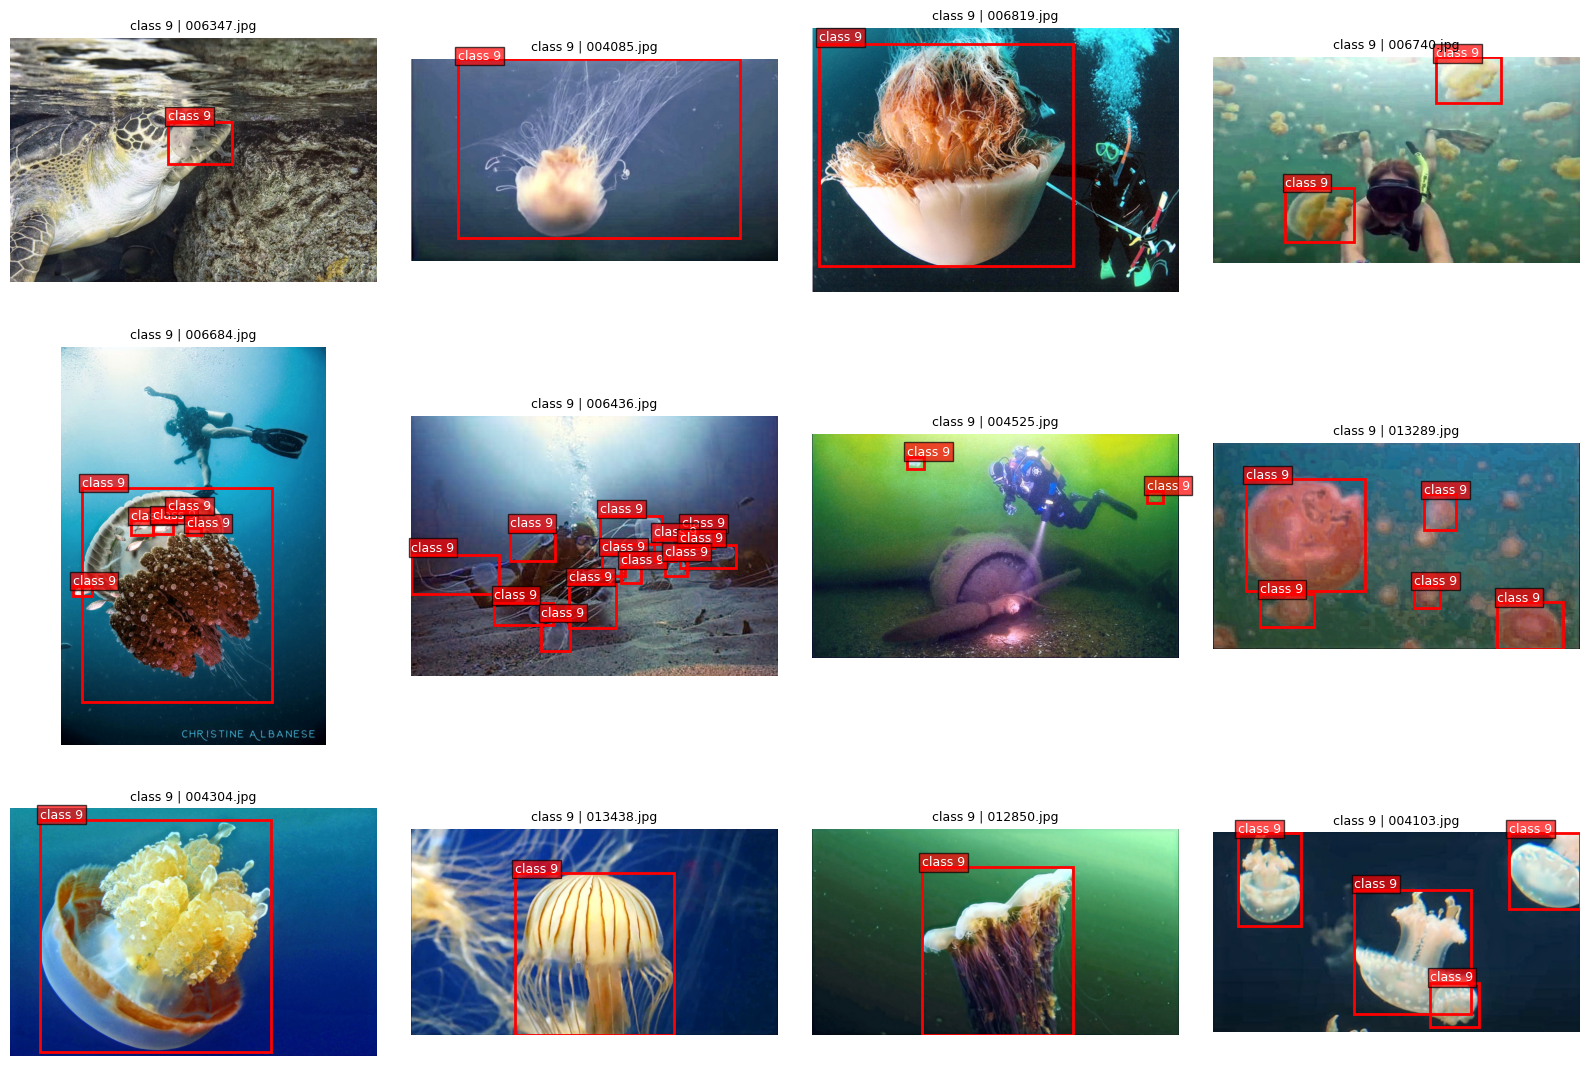

In [52]:
image_dir = "/kaggle/input/datasets/nguynminhc975/ruod-cleaned/output_results/val/images"
label_dir = "/kaggle/input/datasets/nguynminhc975/ruod-cleaned/output_results/val/labels"

show_samples_for_class(
    class_id=9,
    image_dir=image_dir,
    label_dir=label_dir,
    num_samples=12
)

In [3]:
!pip install -q ultralytics

['003440.jpg', '000290.jpg', '007131.jpg', '005496.jpg']
Saving plot to: comparison_results.jpg


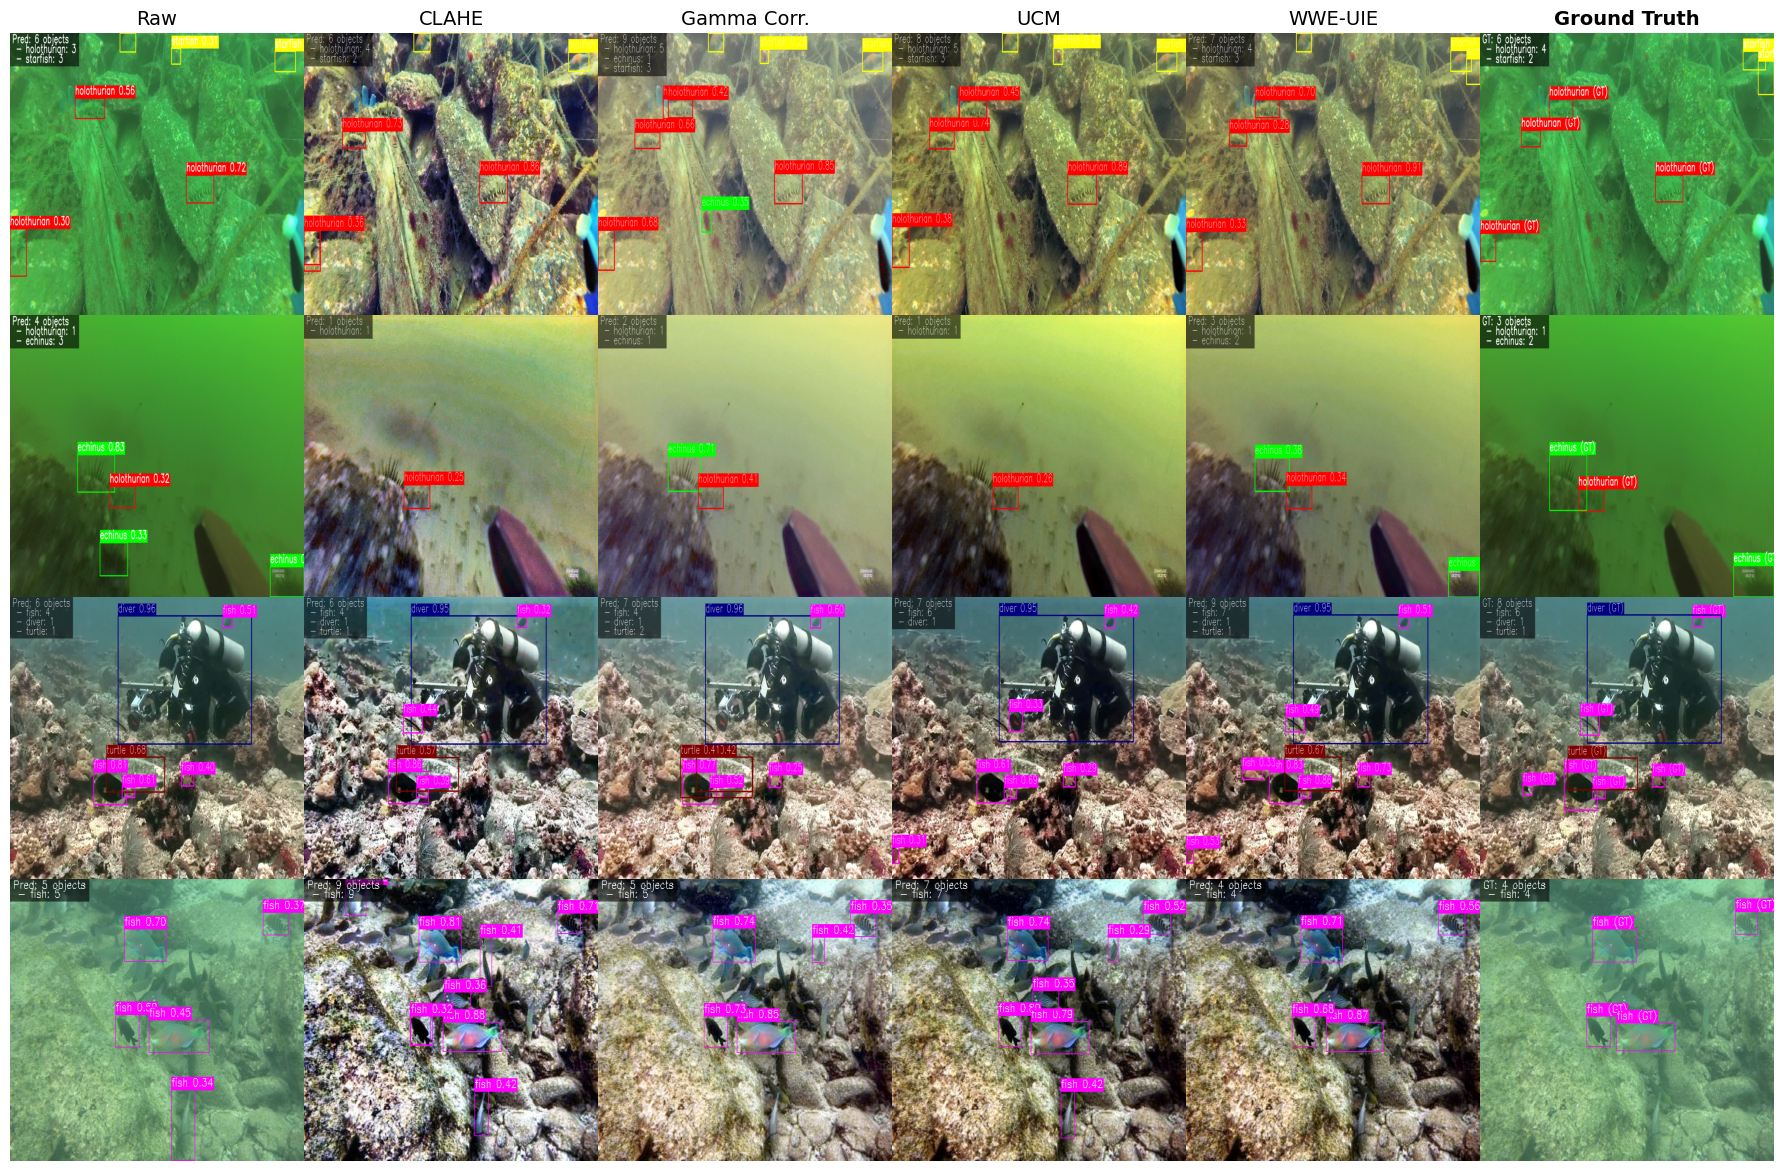

In [32]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import defaultdict
from ultralytics import YOLO

# 1. Define the classes and assign unique colors (BGR format for OpenCV)
CLASS_NAMES = {
    0: 'holothurian',
    1: 'echinus',
    2: 'scallop',
    3: 'starfish',
    4: 'fish',
    5: 'corals',
    6: 'diver',
    7: 'cuttlefish',
    8: 'turtle',
    9: 'jellyfish'
}

# 10 distinct colors in BGR
CLASS_COLORS = {
    0: (0, 0, 255),       # Red
    1: (0, 255, 0),       # Green
    2: (255, 0, 0),       # Blue
    3: (0, 255, 255),     # Yellow
    4: (255, 0, 255),     # Magenta
    5: (255, 255, 0),     # Cyan
    6: (128, 0, 0),       # Navy
    7: (0, 128, 0),       # Dark Green
    8: (0, 0, 128),       # Maroon
    9: (128, 0, 128)      # Purple
}

# 2. Define your ground truth configuration
# Folder containing the .txt annotation files and a folder to pull the base images from
GT_LABELS_FOLDER = "/kaggle/input/datasets/minhducnguyen9705/real-world-underwater-object-detection/ruod/labels/val"
GT_IMAGES_FOLDER = "/kaggle/input/datasets/minhducnguyen9705/real-world-underwater-object-detection/ruod/images/val" # Can be any of your image folders since images are identical

# 3. Define your models and corresponding image folders
CONFIG = [
    {"weight": "/kaggle/input/datasets/nguynminhc975/ruod-yolo26n/epoch40.pt", "folder": "/kaggle/input/datasets/minhducnguyen9705/real-world-underwater-object-detection/ruod/images/val", "title": "Raw"},
    {"weight": "/kaggle/input/datasets/mducnguyen9705/yolo26n-ndl/runs/ruod_yolo26n_clahe/weights/best.pt", "folder": "/kaggle/input/datasets/nguyenluonguy/roud-ndl-cleaned/val/images/images_CLAHE", "title": "CLAHE"},
    {"weight": "/kaggle/input/datasets/mducnguyen9705/yolo26n-ndl/runs/ruod_yolo26n_gc/weights/best.pt", "folder": "/kaggle/input/datasets/nguyenluonguy/roud-ndl-cleaned/val/images/images_GC", "title": "Gamma Corr."},
    {"weight": "/kaggle/input/datasets/mducnguyen9705/yolo26n-ndl/runs/ruod_yolo26n_ucm/weights/best.pt", "folder": "/kaggle/input/datasets/nguyenluonguy/roud-ndl-cleaned/val/images/images_UCM", "title": "UCM"},
    {"weight": "/kaggle/input/datasets/nguynminhc975/ruod-yolo26n/ruod-clean-yolo26n.pt", "folder": "/kaggle/input/datasets/nguynminhc975/ruod-cleaned/output_results/val/images", "title": "WWE-UIE"},
    # Add more models and folders as needed
]

def get_dynamic_scales(h, w):
    """Calculates adaptive line thickness and font scale based on image resolution."""
    avg_dim = (h + w) / 2.0
    thickness = max(1, int(avg_dim / 350))
    font_scale = max(0.5, avg_dim / 1000.0)
    return thickness, font_scale

def draw_metrics_overlay(img, counts, font_scale, thickness, title="Metrics"):
    """Draws a semi-transparent metrics summary box in the top-left corner."""
    if not counts:
        return
        
    # Prepare text
    total = sum(counts.values())
    lines = [f"{title}: {total} objects"]
    for cls_id, count in sorted(counts.items()):
        label = CLASS_NAMES.get(cls_id, f"class_{cls_id}")
        lines.append(f" - {label}: {count}")
        
    # Determine sizing
    margin = int(10 * font_scale)
    line_spacing = int(25 * font_scale)
    max_w = 0
    
    for line in lines:
        (tw, th), _ = cv2.getTextSize(line, cv2.FONT_HERSHEY_SIMPLEX, font_scale, max(1, thickness - 1))
        max_w = max(max_w, tw)
        
    box_w = max_w + margin * 2
    box_h = len(lines) * line_spacing + margin
    
    # Draw transparent background
    overlay = img.copy()
    cv2.rectangle(overlay, (0, 0), (box_w, box_h), (0, 0, 0), -1)
    cv2.addWeighted(overlay, 0.6, img, 0.4, 0, img)
    
    # Draw text lines
    y = margin + int(15 * font_scale)
    for line in lines:
        cv2.putText(img, line, (margin, y), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), max(1, thickness - 1))
        y += line_spacing

def draw_ground_truth(image_path, label_path):
    """Reads YOLO .txt annotations and draws ground-truth bounding boxes."""
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    
    h, w, _ = img.shape
    thickness, font_scale = get_dynamic_scales(h, w)
    class_counts = defaultdict(int)
    
    if Path(label_path).exists():
        with open(label_path, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls_id = int(parts[0])
                class_counts[cls_id] += 1
                
                x_center, y_center, box_w, box_h = map(float, parts[1:5])
                
                x1 = int((x_center - box_w / 2) * w)
                y1 = int((y_center - box_h / 2) * h)
                x2 = int((x_center + box_w / 2) * w)
                y2 = int((y_center + box_h / 2) * h)
                
                color = CLASS_COLORS.get(cls_id, (128, 128, 128))
                label = CLASS_NAMES.get(cls_id, f"class_{cls_id}")
                
                # Draw box with dynamic thickness
                cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
                
                # Draw label with dynamic text scale
                text = f"{label} (GT)"
                (text_width, text_height), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
                cv2.rectangle(img, (x1, y1 - text_height - baseline), (x1 + text_width, y1), color, -1)
                cv2.putText(img, text, (x1, y1 - baseline), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), max(1, thickness - 1))
                
    draw_metrics_overlay(img, class_counts, font_scale, thickness, title="GT")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def draw_predictions(image_path, model):
    """Runs inference and draws bounding boxes with custom colors."""
    img = cv2.imread(str(image_path))
    if img is None:
        return None
        
    h, w, _ = img.shape
    thickness, font_scale = get_dynamic_scales(h, w)
    class_counts = defaultdict(int)
    
    results = model(img, verbose=False)[0]
    
    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        cls_id = int(box.cls[0])
        class_counts[cls_id] += 1
        
        color = CLASS_COLORS.get(cls_id, (128, 128, 128))
        label = CLASS_NAMES.get(cls_id, f"class_{cls_id}")
        
        # Draw box with dynamic thickness
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
        
        # Draw label with dynamic text scale
        text = f"{label} {conf:.2f}"
        (text_width, text_height), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
        cv2.rectangle(img, (x1, y1 - text_height - baseline), (x1 + text_width, y1), color, -1)
        cv2.putText(img, text, (x1, y1 - baseline), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), max(1, thickness - 1))
        
    draw_metrics_overlay(img, class_counts, font_scale, thickness, title="Pred")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def visualize_comparisons(image_names_to_plot, save_path="comparison_results.jpg"):
    """Creates a plot comparing predictions across models vs Ground Truth and saves it."""
    
    models = [YOLO(cfg["weight"]) for cfg in CONFIG]
        
    num_images = len(image_names_to_plot)
    num_cols = len(CONFIG) + 1 
    last_col_idx = len(CONFIG) 
    
    fig, axes = plt.subplots(num_images, num_cols, figsize=(3 * num_cols, 3 * num_images))
    
    if num_images == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, image_name in enumerate(image_names_to_plot):
        
        # --- 1. Draw Model Prediction Columns (Columns 0 to N-1) ---
        for col_idx, cfg in enumerate(CONFIG):
            model = models[col_idx]
            image_path = Path(cfg["folder"]) / image_name
            
            ax_pred = axes[row_idx, col_idx]
            
            if image_path.exists():
                img_with_boxes = draw_predictions(image_path, model)
                if img_with_boxes is not None:
                    ax_pred.imshow(img_with_boxes, aspect='auto')
                else:
                    ax_pred.text(0.5, 0.5, 'Error loading image', ha='center')
            else:
                ax_pred.text(0.5, 0.5, 'Image not found', ha='center')
                
            ax_pred.axis('off')
            ax_pred.set_xticks([])
            ax_pred.set_yticks([])
            
            if row_idx == 0:
                ax_pred.set_title(cfg["title"], fontsize=14)

        # --- 2. Draw Ground Truth Column (Last Column) ---
        ax_gt = axes[row_idx, last_col_idx]
        base_image_path = Path(GT_IMAGES_FOLDER) / image_name
        label_name = Path(image_name).with_suffix('.txt').name
        label_path = Path(GT_LABELS_FOLDER) / label_name
        
        if base_image_path.exists():
            img_gt = draw_ground_truth(base_image_path, label_path)
            if img_gt is not None:
                ax_gt.imshow(img_gt, aspect='auto')
            else:
                ax_gt.text(0.5, 0.5, 'Error loading image', ha='center')
        else:
            ax_gt.text(0.5, 0.5, 'Image not found', ha='center')
            
        ax_gt.axis('off')
        ax_gt.set_xticks([])
        ax_gt.set_yticks([])
        
        if row_idx == 0:
            ax_gt.set_title("Ground Truth", fontsize=14, fontweight='bold')

    # Force absolute zero spacing between all rows and columns
    plt.subplots_adjust(top=0.95, bottom=0.01, left=0.01, right=0.99, hspace=0.0, wspace=0.0) 
    
    # --- SAVE THE FIGURE ---
    # dpi=300 ensures it is saved in high resolution
    # bbox_inches='tight' ensures the edges aren't accidentally cropped off
    print(f"Saving plot to: {save_path}")
    plt.savefig(save_path, dpi=300, format='jpg', bbox_inches='tight')
    
    # Display the plot after saving
    plt.show()

if __name__ == "__main__":
    images_to_test = [
        '003440.jpg', '000290.jpg', '007131.jpg', '005496.jpg'
    ]
    # images_to_test = np.random.choice(os.listdir('/kaggle/input/datasets/minhducnguyen9705/real-world-underwater-object-detection/ruod/images/val'), size=10)
    print(images_to_test)
    visualize_comparisons(images_to_test)

Selected random image: 38.jpg

image 1/1 /kaggle/input/datasets/mducnguyen9705/duo-clean/DUO clean/images/test/38.jpg: 384x640 5 echinuss, 1 scallop, 1 starfish, 12.9ms
Speed: 2.0ms preprocess, 12.9ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)


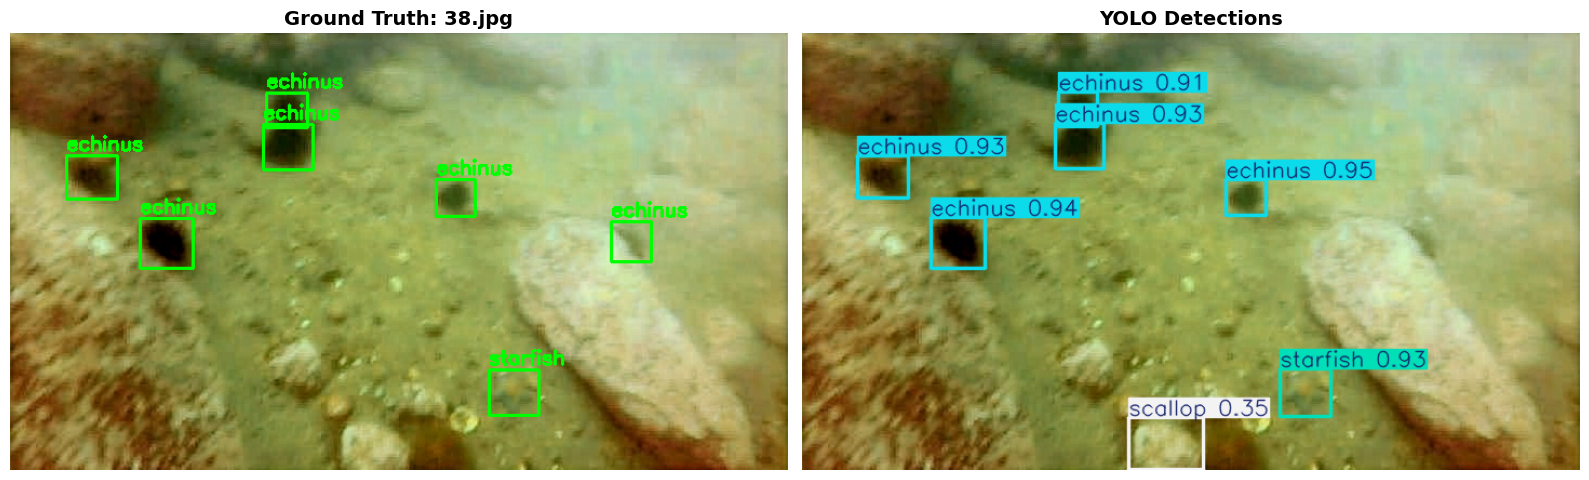

In [52]:
import os
import json
import cv2
import random
import matplotlib.pyplot as plt
from ultralytics import YOLO

def plot_gt_vs_pred(image_folder, coco_json_path, weights_path="yolo26n.pt"):
    """
    Loads a YOLO model, picks a RANDOM image from the folder, and plots a side-by-side 
    comparison of the Ground Truth (from COCO JSON) and the YOLO Predictions.
    """
    
    # 1. Load the YOLO model (will auto-download if not present locally)
    model = YOLO(weights_path)

    # 2. Load COCO annotations
    with open(coco_json_path, 'r') as f:
        coco_data = json.load(f)

    # Map image IDs to their respective annotations
    img_id_to_anns = {}
    for ann in coco_data.get('annotations', []):
        img_id = ann['image_id']
        if img_id not in img_id_to_anns:
            img_id_to_anns[img_id] = []
        img_id_to_anns[img_id].append(ann)

    # Map file names to image IDs and category IDs to class names
    filename_to_img_id = {img['file_name']: img['id'] for img in coco_data.get('images', [])}
    category_id_to_name = {cat['id']: cat['name'] for cat in coco_data.get('categories', [])}

    # 3. Find a RANDOM valid image in the folder that exists in the COCO JSON
    valid_extensions = ('.jpg', '.jpeg', '.png')
    image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(valid_extensions)]
    
    if not image_files:
        print("No images found in the specified folder.")
        return
        
    # Filter for images that actually have entries in the COCO JSON
    valid_annotated_images = [img for img in image_files if img in filename_to_img_id]
            
    if not valid_annotated_images:
        print("No matching image found in the COCO annotations.")
        return

    # Pick a random image from the valid list
    target_image = random.choice(valid_annotated_images)
    print(f"Selected random image: {target_image}")

    # Load the image using OpenCV
    img_path = os.path.join(image_folder, target_image)
    image = cv2.imread(img_path)
    if image is None:
        print(f"Failed to load image at {img_path}")
        return
        
    # Convert BGR (OpenCV default) to RGB for Matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # --- 4. Process Ground Truth (GT) Image ---
    gt_image = image_rgb.copy()
    img_id = filename_to_img_id[target_image]
    annotations = img_id_to_anns.get(img_id, [])

    for ann in annotations:
        bbox = ann.get('bbox', [])
        if len(bbox) == 4:
            # COCO bbox format is [x_min, y_min, width, height]
            x, y, w, h = [int(v) for v in bbox]
            cat_name = category_id_to_name.get(ann['category_id'], "Unknown")
            
            # Draw green bounding box and label
            cv2.rectangle(gt_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(gt_image, cat_name, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # --- 5. Process YOLO Prediction Image ---
    # Run inference directly using Ultralytics
    results = model(img_path)
    
    # Ultralytics results[0].plot() returns a BGR numpy array with all detections perfectly drawn
    pred_image_bgr = results[0].plot()
    pred_image_rgb = cv2.cvtColor(pred_image_bgr, cv2.COLOR_BGR2RGB)

    # --- 6. Plot the Side-by-Side Comparison ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    axes[0].imshow(gt_image)
    axes[0].set_title(f"Ground Truth: {target_image}", fontsize=14, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(pred_image_rgb)
    axes[1].set_title("YOLO Detections", fontsize=14, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# How to run the code:
# ==========================================
if __name__ == "__main__":
    # Your Kaggle directories
    FOLDER_PATH = "/kaggle/input/datasets/mducnguyen9705/duo-clean/DUO clean/images/test"
    JSON_PATH = "/kaggle/input/datasets/mducnguyen9705/duo-clean/DUO clean/annotations/instances_test.json"
    WEIGHTS_PATH = "/kaggle/input/models/mducnguyen9705/yolo26n-duo/pytorch/default/1/yolo26n-clean-duo.pt"
    
    plot_gt_vs_pred(image_folder=FOLDER_PATH, coco_json_path=JSON_PATH, weights_path=WEIGHTS_PATH)

In [55]:
import os
import json
from ultralytics import YOLO
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

def evaluate_yolo_coco(image_folder, gt_json_path, weights_path, output_results_path="predictions.json"):
    """
    Runs YOLO inference on a folder of images, exports the results to a COCO format JSON,
    and calculates standard COCO AP and AR metrics.
    """
    
    # --- 1. Preparation & Category Mapping ---
    print("Loading Ground Truth JSON to map image IDs and categories...")
    with open(gt_json_path, 'r') as f:
        gt_data = json.load(f)
        
    # Map filenames to their exact COCO image_id
    filename_to_img_id = {img['file_name']: img['id'] for img in gt_data.get('images', [])}
    
    # Map YOLO class indices (0, 1, 2...) to COCO category_ids. 
    coco_cat_ids = sorted([cat['id'] for cat in gt_data.get('categories', [])])
    
    # Load the YOLO model
    model = YOLO(weights_path)
    
    valid_extensions = ('.jpg', '.jpeg', '.png')
    image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(valid_extensions)]
    
    coco_results = []
    
    # --- 2. Run Inference and Format Results ---
    print(f"Running inference on {len(image_files)} images...")
    for img_name in tqdm(image_files):
        if img_name not in filename_to_img_id:
            continue 
            
        img_id = filename_to_img_id[img_name]
        img_path = os.path.join(image_folder, img_name)
        
        # Run inference (verbose=False to keep the console clean)
        results = model(img_path, verbose=False)[0]
        
        # Extract bounding boxes
        for box in results.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            w = x2 - x1
            h = y2 - y1
            
            score = box.conf[0].item()
            cls_idx = int(box.cls[0].item())
            
            category_id = coco_cat_ids[cls_idx] if cls_idx < len(coco_cat_ids) else cls_idx
            
            coco_results.append({
                "image_id": img_id,
                "category_id": category_id,
                "bbox": [round(x1, 3), round(y1, 3), round(w, 3), round(h, 3)],
                "score": round(score, 5)
            })

    # Save the predictions to JSON
    print(f"Saving predictions to {output_results_path}...")
    with open(output_results_path, 'w') as f:
        json.dump(coco_results, f)

    if not coco_results:
        print("No detections were made across the dataset. Metrics will be zero.")
        return

    # --- 3. Calculate Metrics using pycocotools ---
    print("\nCalculating COCO Metrics...\n")
    coco_gt = COCO(gt_json_path)               # Load Ground Truth
    
    # --- HOTFIX: Inject missing keys to prevent KeyError ---
    if 'info' not in coco_gt.dataset:
        coco_gt.dataset['info'] = {"description": "Custom dataset info missing"}
    if 'licenses' not in coco_gt.dataset:
        coco_gt.dataset['licenses'] = []
    # -----------------------------------------------------
        
    coco_dt = coco_gt.loadRes(output_results_path) # Load Detections
    
    coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    
    # --- 4. Print Clean Metric Table ---
    stats = coco_eval.stats
    
    print("\nClean metric table:")
    print(f"AP@[0.50:0.95]      : {stats[0]:.4f}")
    print(f"AP@0.50             : {stats[1]:.4f}")
    print(f"AP@0.75             : {stats[2]:.4f}")
    print(f"AP_small            : {stats[3]:.4f}")
    print(f"AP_medium           : {stats[4]:.4f}")
    print(f"AP_large            : {stats[5]:.4f}")
    print(f"AR@1                : {stats[6]:.4f}")
    print(f"AR@10               : {stats[7]:.4f}")
    print(f"AR@100              : {stats[8]:.4f}")
    print(f"AR_small            : {stats[9]:.4f}")
    print(f"AR_medium           : {stats[10]:.4f}")
    print(f"AR_large            : {stats[11]:.4f}")

# ==========================================
# Execution
# ==========================================
if __name__ == "__main__":
    FOLDER_PATH = "/kaggle/input/datasets/mducnguyen9705/detecting-underwater-objects/DUO/images/test"
    JSON_PATH = "/kaggle/input/datasets/mducnguyen9705/detecting-underwater-objects/DUO/annotations/instances_test.json"
    WEIGHTS_PATH = "/kaggle/input/models/mducnguyen9705/yolo26n-duo/pytorch/default/1/yolo26n-raw-duo.pt"
    
    evaluate_yolo_coco(
        image_folder=FOLDER_PATH, 
        gt_json_path=JSON_PATH, 
        weights_path=WEIGHTS_PATH
    )

Loading Ground Truth JSON to map image IDs and categories...
Running inference on 1111 images...


100%|██████████| 1111/1111 [00:53<00:00, 20.88it/s]


Saving predictions to predictions.json...

Calculating COCO Metrics...

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.34s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.82s).
Accumulating evaluation results...
DONE (t=0.29s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.596
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.753
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.668
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.354
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.610
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.588
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.212
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] =